<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/normal_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# Change this path according to your Drive folder
df = pd.read_csv('/content/drive/MyDrive/Dataset/continuous dataset.csv')   # <-- yahan apna exact path daal do

# Datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Basic features
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_holiday'] = df['holiday']

# Lag features
df['lag_1'] = df['nat_demand'].shift(1)
df['lag_24'] = df['nat_demand'].shift(24)
df['lag_168'] = df['nat_demand'].shift(168)
df['rolling_mean_24'] = df['nat_demand'].rolling(window=24).mean()

df = df.dropna().reset_index(drop=True)

print("✅ Data loaded and features created!")
print("Shape:", df.shape)

✅ Data loaded and features created!
Shape: (47880, 26)


In [ ]:
# Peak definition
peak_threshold = df['nat_demand'].quantile(0.90)
df['is_peak'] = (df['nat_demand'] > peak_threshold).astype(int)

feature_columns = ['hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday',
                   'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
                   'T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
                   'T2M_san','QV2M_san','TQL_san','W2M_san',
                   'T2M_dav','QV2M_dav','TQL_dav','W2M_dav']

X = df[feature_columns]
y = df['nat_demand']

# Time-based split
train_size = int(len(df) * 0.80)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]
peak_test_mask = df['is_peak'].iloc[train_size:].values

print("✅ Train-Test Split Done!")
print("Train:", len(X_train), "Test:", len(X_test))

✅ Train-Test Split Done!
Train: 38304 Test: 9576


In [ ]:
# ====================== FIXED STEP 4 ======================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

results = {}

print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = (abs(y_test - pred) / y_test).mean() * 100

    peak_pred = pred[peak_test_mask == 1]
    peak_actual = y_test[peak_test_mask == 1]
    peak_mape = (abs(peak_actual - peak_pred) / peak_actual).mean() * 100 if len(peak_actual) > 0 else 0

    results[name] = {
        'MAE': round(mae, 5),
        'RMSE': round(rmse, 5),
        'MAPE (%)': round(mape, 5),
        'Peak MAPE (%)': round(peak_mape, 5)
    }

    print(f"{name} done.")

results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("FINAL RESULTS TABLE")
print("="*60)
print(results_df)

# Best model strictly by Peak MAPE
best_name = results_df['Peak MAPE (%)'].idxmin()
print(f"\n🏆 Best Model for Peak Forecasting: {best_name}")

Training models...

Training Linear Regression...
Linear Regression done.
Training Random Forest...
Random Forest done.
Training XGBoost...
XGBoost done.
Training KNN...
KNN done.

FINAL RESULTS TABLE
                        MAE      RMSE  MAPE (%)  Peak MAPE (%)
Linear Regression  34.02725  43.99645   2.81446        2.52217
Random Forest      19.22689  27.10033   1.60915        1.34280
XGBoost            18.49580  25.66619   1.54502        1.33626
KNN                31.89393  44.47913   2.64817        2.32363

🏆 Best Model for Peak Forecasting: XGBoost


Using Best Model: XGBoost for graphs



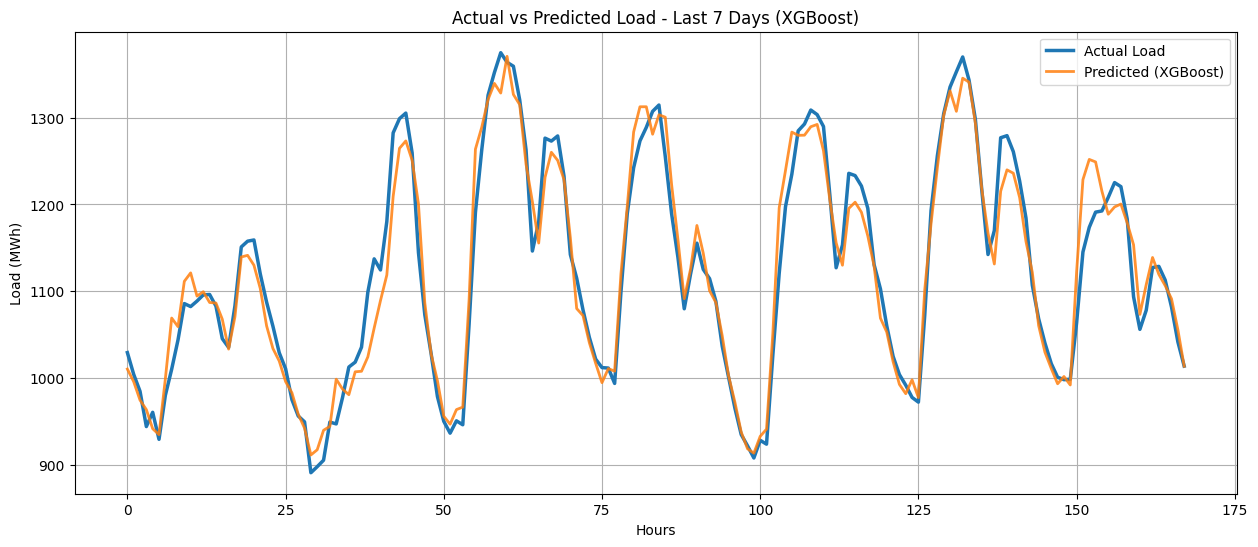

/tmp/ipykernel_11799/1887393182.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


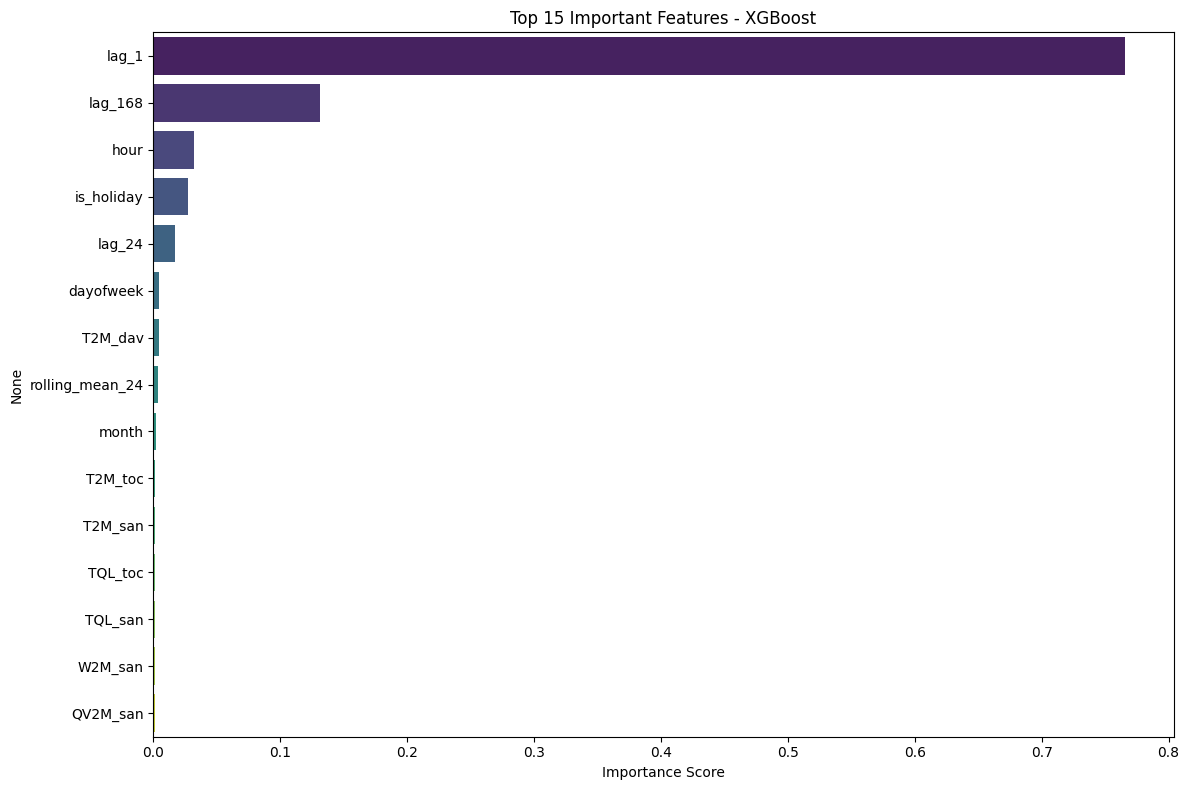


Top 10 Important Features:
lag_1              0.765709
lag_168            0.131419
hour               0.032188
is_holiday         0.027254
lag_24             0.016952
dayofweek          0.004773
T2M_dav            0.004225
rolling_mean_24    0.003627
month              0.002335
T2M_toc            0.001519
dtype: float32

✅ All results and model saved in Google Drive!


In [ ]:
# ====================== FIXED STEP 5 ======================
best_model = models[best_name]
best_pred = best_model.predict(X_test)

print(f"Using Best Model: {best_name} for graphs\n")

# 1. Actual vs Predicted Plot
plt.figure(figsize=(15, 6))
last = 168
plt.plot(y_test.iloc[-last:].values, label='Actual Load', linewidth=2.5)
plt.plot(best_pred[-last:], label=f'Predicted ({best_name})', linewidth=2, alpha=0.85)
plt.title(f'Actual vs Predicted Load - Last 7 Days ({best_name})')
plt.xlabel('Hours')
plt.ylabel('Load (MWh)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Feature Importance
if best_name in ["Random Forest", "XGBoost"]:
    importance = best_model.feature_importances_
    feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False).head(15)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title(f'Top 15 Important Features - {best_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Important Features:")
    print(feat_imp.head(10))

# Save
results_df.to_csv('/content/drive/MyDrive/load_forecasting_results.csv')
joblib.dump(best_model, '/content/drive/MyDrive/best_load_model.pkl')
print("\n✅ All results and model saved in Google Drive!")

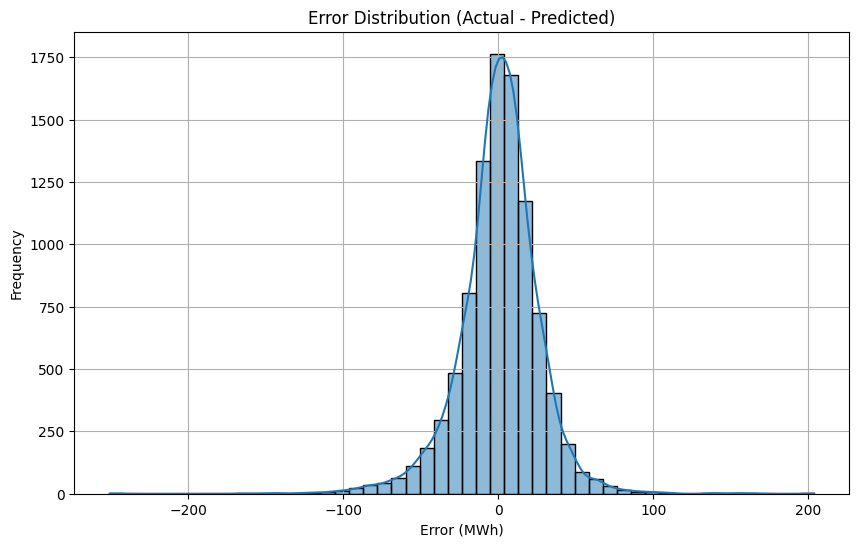

Mean Error: 0.8 MWh


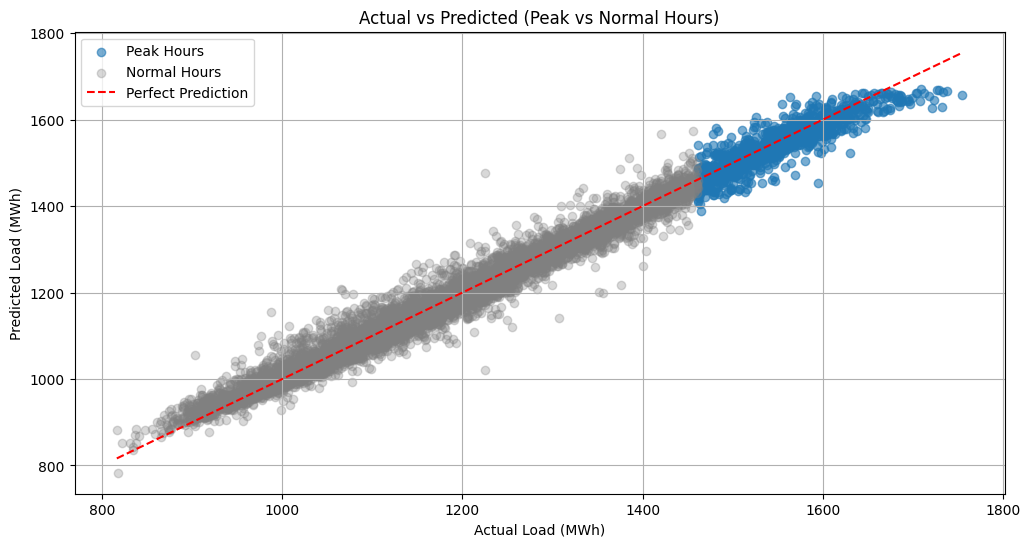

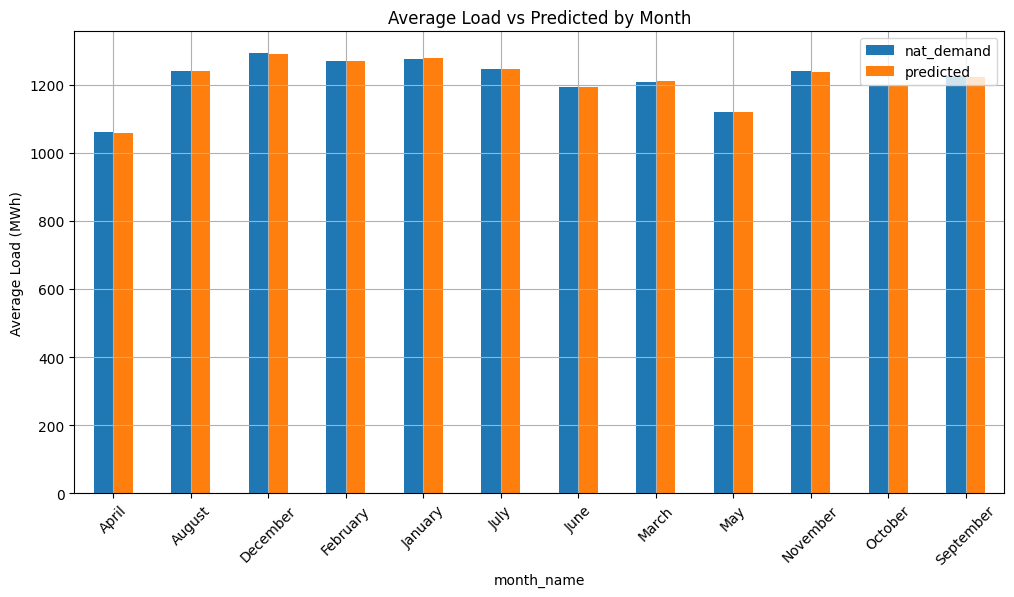

In [ ]:


# 1. Error Distribution Plot
errors = y_test - best_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, bins=50)
plt.title('Error Distribution (Actual - Predicted)')
plt.xlabel('Error (MWh)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("Mean Error:", round(errors.mean(), 2), "MWh")

# 2. Peak Hours Performance
plt.figure(figsize=(12, 6))
plt.scatter(y_test[peak_test_mask==1], best_pred[peak_test_mask==1], alpha=0.6, label='Peak Hours')
plt.scatter(y_test[peak_test_mask==0], best_pred[peak_test_mask==0], alpha=0.3, label='Normal Hours', color='gray')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted (Peak vs Normal Hours)')
plt.xlabel('Actual Load (MWh)')
plt.ylabel('Predicted Load (MWh)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Monthly Average Performance
df_test = df.iloc[train_size:].copy()
df_test['predicted'] = best_pred
df_test['month_name'] = df_test['datetime'].dt.month_name()

monthly = df_test.groupby('month_name')[['nat_demand', 'predicted']].mean()
monthly.plot(kind='bar', figsize=(12,6))
plt.title('Average Load vs Predicted by Month')
plt.ylabel('Average Load (MWh)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

